<a href="https://colab.research.google.com/github/ramgeethatamatam-rgb/tmdb_eda-assignment/blob/main/tmdb_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 First 5 rows from API data:
        id                             title release_date  popularity  \
0  1265609                       War Machine   2026-02-12    374.3784   
1   875828  Peaky Blinders: The Immortal Man   2026-03-05    370.3607   
2   687163                 Project Hail Mary   2026-03-15    323.2718   
3  1290821                           Shelter   2026-01-28    323.2197   
4    83533              Avatar: Fire and Ash   2025-12-17    319.3325   

   vote_average  vote_count      genre_ids  
0         7.254        1081  [28, 878, 53]  
1         7.447         300       [80, 18]  
2         8.200         313      [878, 12]  
3         6.607         360   [28, 80, 53]  
4         7.266        1914  [878, 12, 14]  

 First 5 rows from DB:
        id                             title release_date  popularity  \
0  1265609                       War Machine   2026-02-12    374.3784   
1   875828  Peaky Blinders: The Immortal Man   2026-03-05    370.3607   
2   687163        

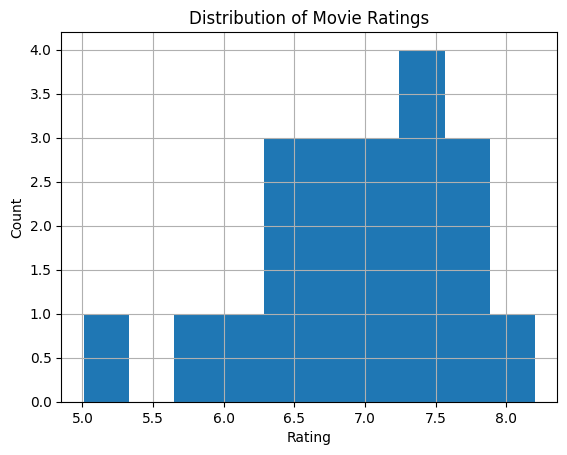

In [5]:
# ==============================
# TMDB API PIPELINE + EDA (ALL-IN-ONE)
# ==============================

# 🔹 Import Libraries
import requests
import pandas as pd
import sqlite3
from google.colab import userdata


API_KEY = userdata.get('TMDB_API_KEY')

# ==============================
# TASK 1 — BUILD PIPELINE
# ==============================

# 🔹 Step 1: Fetch Data from TMDB API
url = "https://api.themoviedb.org/3/discover/movie"

params = {
    "api_key": API_KEY,
    "language": "en-US",
    "page": 1   # gives ~20 movies
}

response = requests.get(url, params=params)
data = response.json()

# Check for API errors
if response.status_code != 200:
    print(f"API Error: {data.get('status_message', 'Unknown error')}")
    print("Please ensure your API_KEY is valid and has notebook access enabled in Colab secrets.")
    df = pd.DataFrame() # Initialize empty df to avoid subsequent errors
else:
    # 🔹 Step 2: Convert JSON → DataFrame
    if 'results' in data:
        movies_list = []

        for movie in data['results']:
            movies_list.append({
                "id": movie.get("id"),
                "title": movie.get("title"),
                "release_date": movie.get("release_date"),
                "popularity": movie.get("popularity"),
                "vote_average": movie.get("vote_average"),
                "vote_count": movie.get("vote_count"),
                "genre_ids": movie.get("genre_ids")
            })

        df = pd.DataFrame(movies_list)

        # Convert list of genre_ids to string for SQLite compatibility
        df['genre_ids'] = df['genre_ids'].apply(lambda x: str(x))

    else:
        print("No 'results' key found in API response. DataFrame will be empty.")
        df = pd.DataFrame() # Ensure df is defined even if no results

print("\n First 5 rows from API data:")
print(df.head())

# Proceed only if DataFrame is not empty to avoid SQL errors
if not df.empty:
    # 🔹 Step 3: Save to SQLite Database
    conn = sqlite3.connect("movies.db")
    df.to_sql("movies", conn, if_exists="replace", index=False)

    # ==============================
    # TASK 2 — EDA
    # ==============================

    # 🔹 Step 4: Load Data from SQLite
    df = pd.read_sql("SELECT * FROM movies", conn)

    # Convert genre_ids back to list after loading from SQLite
    df['genre_ids'] = df['genre_ids'].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # 🔹 1. Display first 5 rows
    print("\n First 5 rows from DB:")
    print(df.head())

    # 🔹 2. Summary statistics
    print("\n Summary Statistics:")
    print(df.describe())

    # 🔹 3. Count movies per genre
    # Explode list into rows
    df_exploded = df.explode('genre_ids')

    # Count genres
    genre_counts = df_exploded['genre_ids'].value_counts()

    print("\n🎬 Movies per Genre (genre_id):")
    print(genre_counts)

    # 🔹 4. Missing values
    print("\n Missing Values:")
    print(df.isnull().sum())

# Visualization

import matplotlib.pyplot as plt

df["vote_average"].hist()
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()
